# Niamey level
<!-- markdownlint-disable MD013 -->

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from src.datasources import grdc, glofas
from src.utils.rp_calc import calculate_one_group_rp
from src.utils.rating_curve import calculate_stage
from src.constants import *

In [3]:
df_grdc = grdc.load_grdc(station_id=NIAMEY_GRDC_ID)

In [4]:
def date_to_season(date):
    if date.month < 6:
        return date.year - 1
    else:
        return date.year

In [5]:
df_grdc["season"] = df_grdc["time"].apply(date_to_season)

In [6]:
def set_flood_phase(date):
    if date.month >= 6 and date.month <= 9:
        return "l"
    else:
        return "g"

In [7]:
df_grdc["flood_type"] = df_grdc["time"].apply(set_flood_phase)

In [8]:
df_grdc

,time,runoff_mean,season,flood_type
0,1929-01-01,1691.160034,1928,g
1,1929-01-02,NaN,1928,g
2,1929-01-03,NaN,1928,g
3,1929-01-04,NaN,1928,g
4,1929-01-05,NaN,1928,g
...,...,...,...,...
35227,2025-06-13,119.000000,2025,l
35228,2025-06-14,115.000000,2025,l
35229,2025-06-15,134.000000,2025,l
35230,2025-06-16,165.000000,2025,l


In [48]:
min_year = 1979

In [49]:
df_plot = df_grdc[df_grdc["season"] >= min_year].copy()
df_plot["plot_date"] = df_plot["time"].map(
    lambda x: pd.Timestamp(
        year=1904,
        month=x.month,
        day=x.day,
    )
)

In [50]:
df_plot["level"] = calculate_stage(df_plot["runoff_mean"])

[None, None]

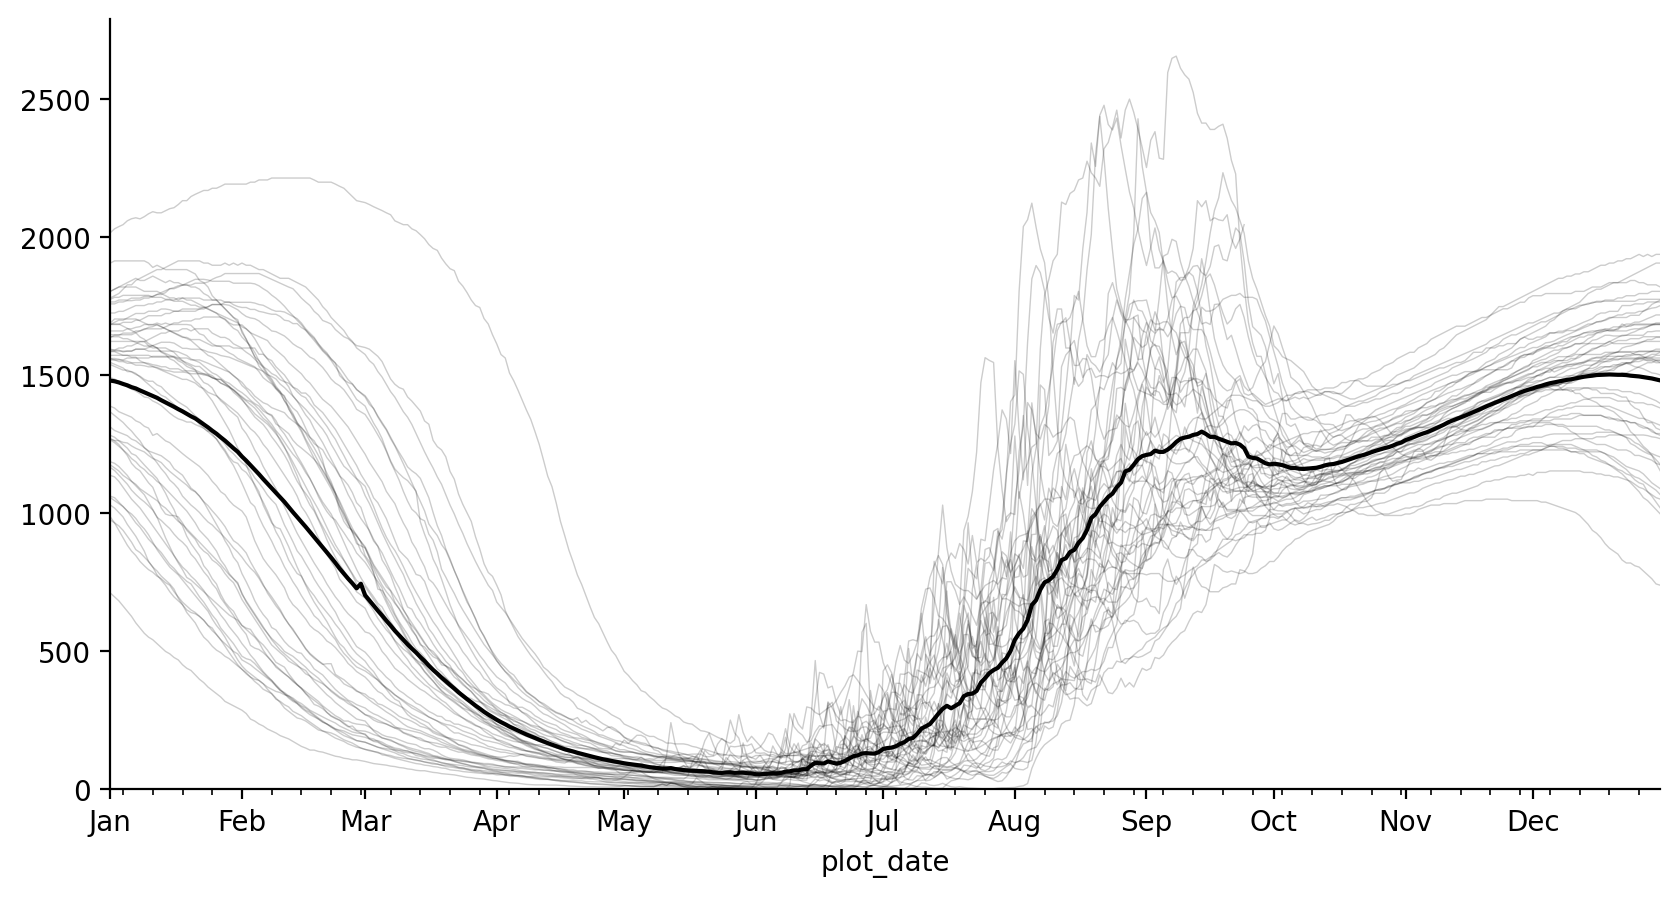

In [51]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for year, group in df_plot.groupby(df_plot["time"].dt.year):
    group.plot(
        x="plot_date",
        y="runoff_mean",
        ax=ax,
        legend=False,
        color="k",
        alpha=0.2,
        linewidth=0.5,
    )

df_plot.groupby("plot_date")["runoff_mean"].mean().plot(ax=ax, color="k")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim(bottom=0)
ax.set_xlim((df_plot["plot_date"].min(), df_plot["plot_date"].max()))
[ax.spines[x].set_visible(False) for x in ["top", "right"]]

[None, None]

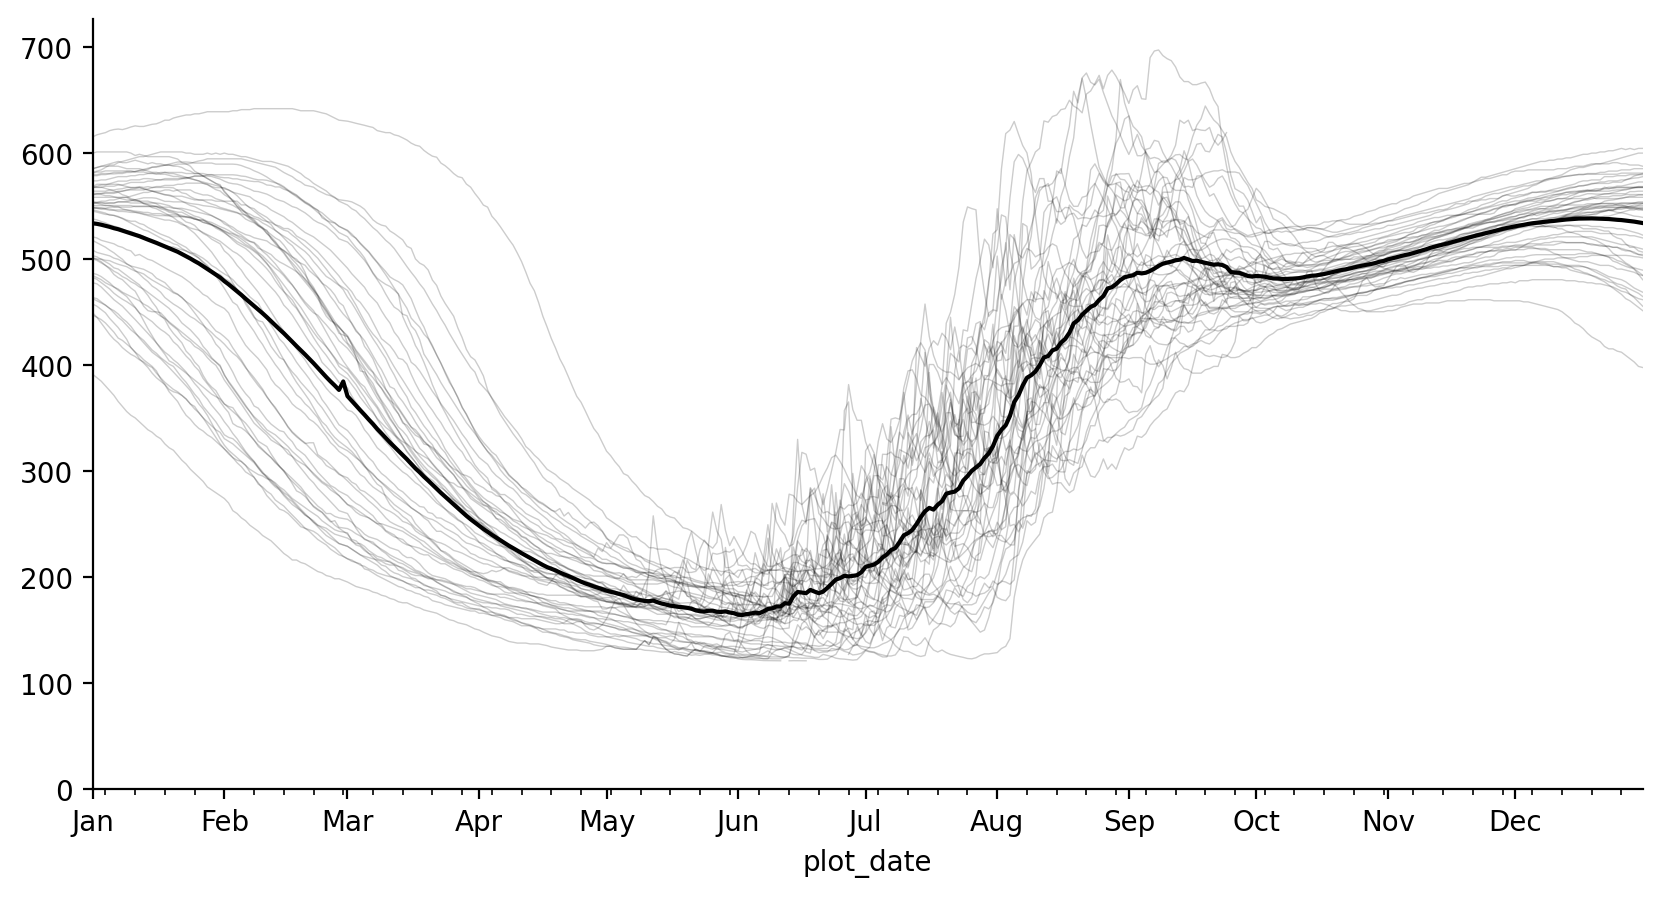

In [52]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for year, group in df_plot.groupby(df_plot["time"].dt.year):
    group.plot(
        x="plot_date",
        y="level",
        ax=ax,
        legend=False,
        color="k",
        alpha=0.2,
        linewidth=0.5,
    )

df_plot.groupby("plot_date")["level"].mean().plot(ax=ax, color="k")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim(bottom=0)
ax.set_xlim((df_plot["plot_date"].min(), df_plot["plot_date"].max()))
[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [53]:
df_locale = df_grdc[df_grdc["flood_type"] == "l"]

In [54]:
df_locale_peaks = (
    df_locale.groupby(df_locale["time"].dt.year)["runoff_mean"]
    .max()
    .reset_index()
    .rename(columns={"time": "year"})
)

In [55]:
df_locale_peaks = calculate_one_group_rp(
    df_locale_peaks, col_name="runoff_mean", ascending=False
)

In [56]:
df_locale_peaks["level"] = calculate_stage(df_locale_peaks["runoff_mean"])

In [57]:
df_locale_peaks.sort_values("runoff_mean_rp")

,year,runoff_mean,runoff_mean_rank,runoff_mean_rp,level
96,2025,175.000000,91.0,1.076923,231.043880
57,1986,825.760010,90.0,1.088889,416.678664
15,1944,829.250000,89.0,1.101124,417.419452
12,1941,869.369995,88.0,1.113636,425.829675
13,1942,898.030029,87.0,1.126437,431.723272
...,...,...,...,...,...
4,1933,NaN,NaN,NaN,NaN
8,1937,NaN,NaN,NaN,NaN
9,1938,NaN,NaN,NaN,NaN
10,1939,NaN,NaN,NaN,NaN


In [58]:
df_recent = df_grdc[
    (df_grdc["season"] >= min_year) & (df_grdc["season"] < 2025)
].copy()

In [59]:
df_recent["level"] = calculate_stage(df_recent["runoff_mean"])

In [60]:
df_peaks = df_recent.groupby("season")["level"].max().reset_index()

In [61]:
df_peaks_l = (
    df_recent[df_recent["flood_type"] == "l"]
    .groupby("season")["level"]
    .max()
    .reset_index()
)

In [62]:
df_peaks_g = (
    df_recent[df_recent["flood_type"] == "g"]
    .groupby("season")["level"]
    .max()
    .reset_index()
)

In [63]:
df_peaks_l = calculate_one_group_rp(
    df_peaks_l, col_name="level", ascending=False
)

In [64]:
df_peaks = calculate_one_group_rp(df_peaks, col_name="level", ascending=False)

In [65]:
df_peaks.sort_values("level_rank")

,season,level,level_rank,level_rp
41,2020,697.395561,1.0,47.000000
33,2012,675.682032,2.0,23.500000
45,2024,670.614124,3.0,15.666667
34,2013,669.568384,4.0,11.750000
19,1998,644.565737,5.0,9.400000
40,2019,635.187248,6.0,7.833333
36,2015,629.987016,7.0,6.714286
31,2010,612.165700,8.0,5.875000
20,1999,604.576334,9.0,5.222222
37,2016,602.359136,10.0,4.700000


In [66]:
thresh = 600

In [67]:
total_years = df_recent["time"].dt.year.nunique()

In [68]:
(total_years + 1) / df_recent[
    (df_recent["level"] >= thresh) & (df_recent["flood_type"] == "l")
]["season"].nunique()

5.333333333333333

In [69]:
(total_years + 1) / df_recent[
    (df_recent["level"] >= thresh) & (df_recent["flood_type"] == "g")
]["season"].nunique()

12.0

In [70]:
def get_flood_type_rp(thresh, flood_type):
    trig_years = df_recent[
        (df_recent["level"] >= thresh)
        & (df_recent["flood_type"] == flood_type)
    ]["season"].nunique()
    if trig_years == 0:
        return np.inf
    else:
        return (total_years + 1) / trig_years

In [71]:
df_peaks["l_rp"] = df_peaks["level"].apply(get_flood_type_rp, flood_type="l")
df_peaks["g_rp"] = df_peaks["level"].apply(get_flood_type_rp, flood_type="g")

In [72]:
df_peaks = df_peaks.sort_values("level_rp")

In [73]:
df_peaks

,season,level,level_rank,level_rp,l_rp,g_rp
8,1987,480.750026,46.0,1.021739,1.371429,1.043478
11,1990,494.257823,45.0,1.044444,1.655172,1.066667
10,1989,496.565245,44.0,1.068182,1.714286,1.090909
4,1983,497.713598,43.0,1.093023,1.777778,1.116279
7,1986,498.860728,42.0,1.119048,1.777778,1.142857
32,2011,503.665329,41.0,1.146341,1.777778,1.170732
5,1984,504.547564,40.0,1.175000,1.777778,1.200000
14,1993,511.277968,39.0,1.205128,2.086957,1.297297
3,1982,515.709981,38.0,1.236842,2.086957,1.333333
12,1991,516.812615,37.0,1.270270,2.086957,1.371429


In [74]:
rp = np.interp(600, df_peaks["level"], df_peaks["level_rp"])

In [75]:
rp

3.9856332415697793

In [76]:
len(df_peaks[df_peaks["level"] >= thresh])

12

In [77]:
len(df_peaks)

46

In [78]:
rp_l = np.interp(600, df_peaks["level"], df_peaks["l_rp"])

In [79]:
rp_g = np.interp(600, df_peaks["level"], df_peaks["g_rp"])

In [80]:
print(rp_l, rp_g)

5.218739817416034 12.0


[None, None]

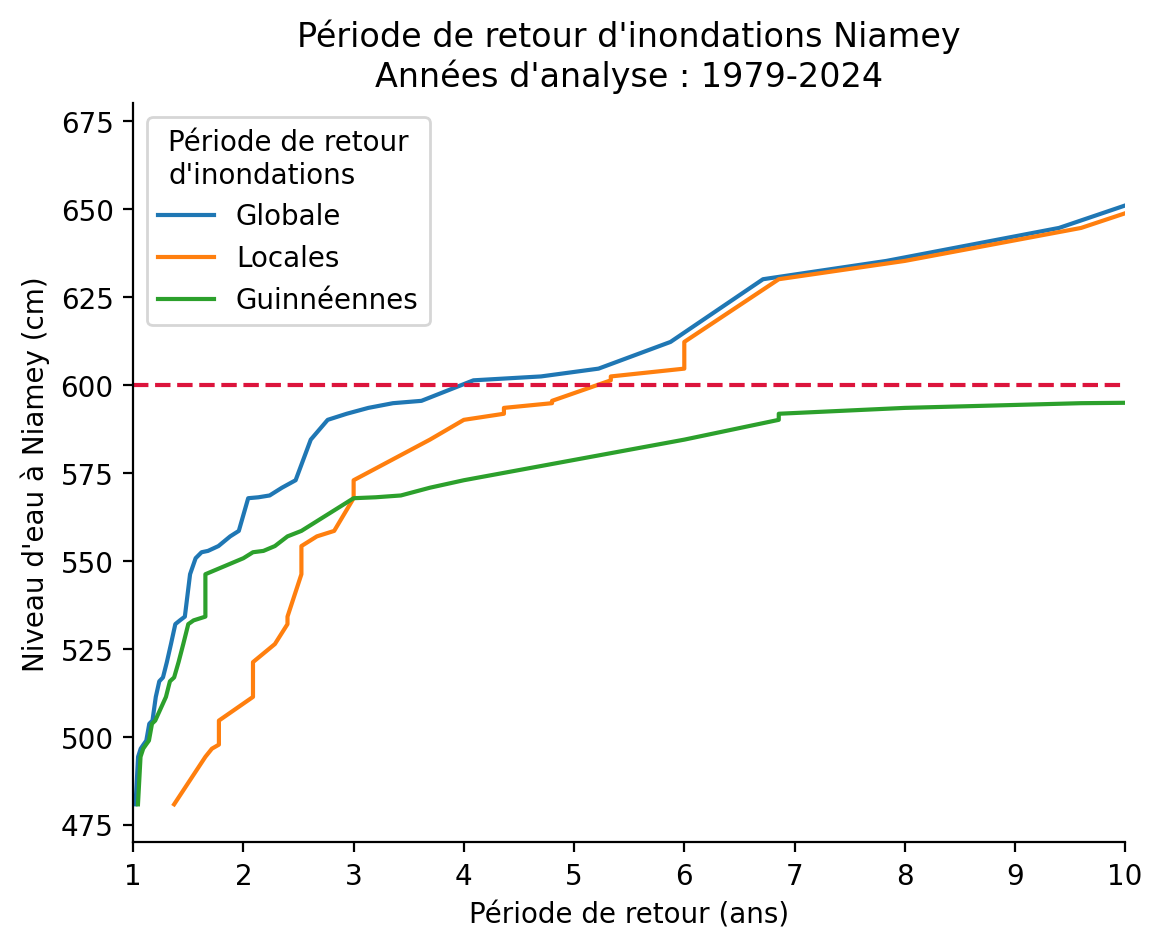

In [81]:
fig, ax = plt.subplots(dpi=200)
for col, label in [
    ("level_rp", "Globale"),
    ("l_rp", "Locales"),
    ("g_rp", "Guinnéennes"),
]:
    df_peaks.sort_values("level").plot(x=col, y="level", ax=ax, label=label)

ax.set_xlabel("Période de retour (ans)")
ax.set_ylabel("Niveau d'eau à Niamey (cm)")

ax.set_xlim((1, 10))
ax.set_ylim(top=680)

ax.axhline(600, linestyle="--", color="crimson")

ax.legend(title="Période de retour\nd'inondations")

ax.set_title(
    "Période de retour d'inondations Niamey\nAnnées d'analyse : 1979-2024"
)

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [82]:
minval, maxval = (
    min(df_peaks_g["level"].min(), df_peaks_l["level"].min()),
    df_peaks["level"].max(),
)
span = maxval - minval
minlim, maxlim = (minval - span * 0.1, maxval + span * 0.1)
lims = (minlim, maxlim)

In [83]:
xcolor, ycolor = "crimson", "darkorange"

[None, None]

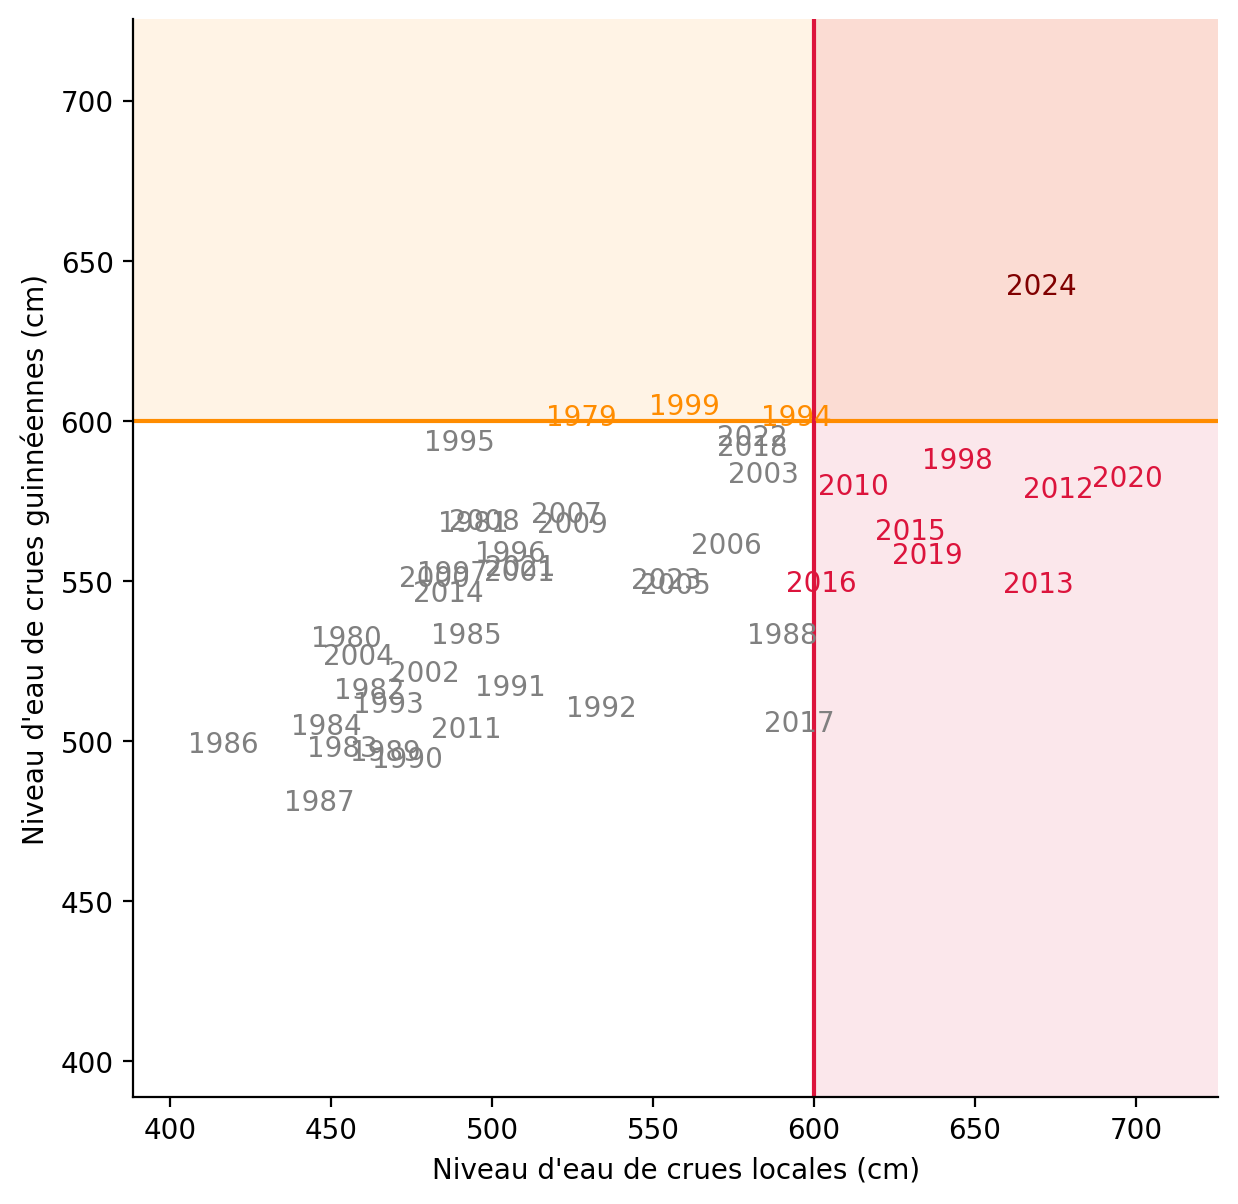

In [84]:
fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

for season in df_peaks["season"].unique():
    color = "grey"
    l_peak = df_peaks_l.set_index("season").loc[season, "level"]
    g_peak = df_peaks_g.set_index("season").loc[season, "level"]
    if l_peak >= thresh:
        color = xcolor
    if g_peak >= thresh:
        color = ycolor
    if (l_peak >= thresh) & (g_peak >= thresh):
        color = "maroon"
    ax.annotate(
        season, (l_peak, g_peak), va="center", ha="center", color=color
    )

ax.axhline(thresh, color=ycolor)
ax.axhspan(thresh, maxlim, facecolor=ycolor, alpha=0.1)

ax.axvline(thresh, color=xcolor)
ax.axvspan(thresh, maxlim, facecolor=xcolor, alpha=0.1)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Niveau d'eau de crues locales (cm)")
ax.set_ylabel("Niveau d'eau de crues guinnéennes (cm)")

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [59]:
df_recent

,time,runoff_mean,season,flood_type,level
18413,1979-06-01,24.420000,1979,l,144.867346
18414,1979-06-02,22.330000,1979,l,143.093793
18415,1979-06-03,20.240000,1979,l,141.284662
18416,1979-06-04,19.200001,1979,l,140.370486
18417,1979-06-05,21.290001,1979,l,142.198138
...,...,...,...,...,...
35210,2025-05-27,179.500000,2024,g,232.985753
35211,2025-05-28,271.000000,2024,g,268.713677
35212,2025-05-29,207.000000,2024,g,244.425448
35213,2025-05-30,172.500000,2024,g,229.955859


In [100]:
def get_first_dates(
    df, level, level_col="level", date_col="time", season_col="season"
):
    dicts = []
    for season, group in df.groupby(season_col):
        dff = group[group[level_col] >= level]
        if not dff.empty:
            dicts.append({"first_date": dff[date_col].min(), "season": season})
    return pd.DataFrame(dicts)

In [103]:
df_trig_dates_grdc = get_first_dates(
    df_recent[df_recent["flood_type"] == "l"], level=thresh
)

In [105]:
df_trig_dates_grdc

,first_date,season
0,1998-09-15,1998
1,2010-09-05,2010
2,2012-08-17,2012
3,2013-08-29,2013
4,2015-08-03,2015
5,2016-09-14,2016
6,2019-08-29,2019
7,2020-08-10,2020
8,2024-08-19,2024


In [63]:
df_gf = glofas.load_reanalysis(station_name="garbekourou")

In [64]:
df_gf

,time,dis24
0,1979-01-01,0.656250
1,1979-01-02,0.625000
2,1979-01-03,0.593750
3,1979-01-04,0.562500
4,1979-01-05,0.546875
...,...,...
16797,2024-12-27,0.054688
16798,2024-12-28,0.054688
16799,2024-12-29,0.046875
16800,2024-12-30,0.046875


In [65]:
df_gf_peaks = df_gf.groupby(df_gf["time"].dt.year)["dis24"].max().reset_index()

In [66]:
df_gf_peaks = calculate_one_group_rp(
    df_gf_peaks, col_name="dis24", ascending=False
)

In [67]:
df_gf_peaks = df_gf_peaks.sort_values("dis24_rp")

In [68]:
gf_thresh = np.interp(rp_l, df_gf_peaks["dis24_rp"], df_gf_peaks["dis24"])

In [69]:
gf_thresh

926.0924540854688

In [70]:
dicts = []
for season, group in df_gf.groupby(df_gf["time"].dt.year):
    dff = group[group["dis24"] >= gf_thresh]
    if not dff.empty:
        dicts.append({"trig_date": dff["time"].min(), "season": season})

In [109]:
df_trig_dates_gf = pd.DataFrame(dicts)

In [110]:
df_trig_dates_gf

,initial_date,season
0,1998-09-15,1998
1,2010-09-05,2010
2,2012-08-17,2012
3,2013-08-29,2013
4,2015-08-03,2015
5,2016-09-14,2016
6,2019-08-29,2019
7,2020-08-10,2020
8,2024-08-19,2024


In [73]:
df_trig_dates = df_trig_dates_grdc.merge(
    df_trig_dates_gf, on="season", suffixes=("_grdc", "_gf"), how="outer"
)

In [74]:
df_trig_dates["grdc_lt"] = (
    df_trig_dates["trig_date_grdc"] - df_trig_dates["trig_date_gf"]
)

In [75]:
df_trig_dates

,trig_date_grdc,season,trig_date_gf,grdc_lt
0,NaT,1989,1989-08-27,NaT
1,1998-09-15,1998,1998-09-12,3 days
2,NaT,1999,1999-08-29,NaT
3,NaT,2000,2000-08-03,NaT
4,NaT,2009,2009-09-04,NaT
5,2010-09-05,2010,2010-09-03,2 days
6,2012-08-17,2012,2012-08-17,0 days
7,2013-08-29,2013,NaT,NaT
8,2015-08-03,2015,NaT,NaT
9,2016-09-14,2016,NaT,NaT


In [76]:
df_trig_dates["grdc_lt"].mean()

Timedelta('0 days 12:00:00')

## Plot timing after certain level

In [113]:
df_l_recent = df_recent[df_recent["flood_type"] == "l"]
df_g_recent = df_recent[df_recent["flood_type"] == "g"]

In [134]:
df_peaks_l

,season,level,level_rank,level_rp
7,1986,416.678664,46.0,1.021739
8,1987,446.328382,45.0,1.044444
5,1984,448.434734,44.0,1.068182
4,1983,453.657010,43.0,1.093023
1,1980,454.693320,42.0,1.119048
25,2004,458.480637,41.0,1.146341
3,1982,461.872081,40.0,1.175000
10,1989,466.923035,39.0,1.205128
14,1993,467.926199,38.0,1.236842
11,1990,473.893288,37.0,1.270270


In [138]:
df_l_recent.loc[df_l_recent.groupby("season")["level"].idxmax()]

,time,runoff_mean,season,flood_type,level
18525,1979-09-21,1427.930054,1979,l,527.688398
18900,1980-09-30,1014.020020,1980,l,454.693320
19265,1981-09-30,1229.810059,1981,l,494.257823
19630,1982-09-30,1051.670044,1982,l,461.872081
19988,1983-09-23,1008.640015,1983,l,453.657010
20361,1984-09-30,981.739990,1984,l,448.434734
20715,1985-09-19,1216.599976,1985,l,491.938253
21091,1986-09-30,825.760010,1986,l,416.678664
21453,1987-09-27,970.989990,1987,l,446.328382
21785,1988-08-24,1835.959961,1988,l,590.023173


In [164]:
def get_peak_dates(df, level_col="level", season_col="season"):
    df_out = df.loc[df.groupby(season_col)[level_col].idxmax()]
    df_out = df_out.rename(
        columns={"time": "peak_date", "level": "peak_level"}
    )[["peak_date", "season", "peak_level"]]
    return df_out

In [165]:
df_l_red_first = get_first_dates(df_l_recent, level=620)
df_l_trig_first = get_first_dates(df_l_recent, level=thresh)
df_l_peak = get_peak_dates(df_l_recent)

In [166]:
df_g_red_first = get_first_dates(df_g_recent, level=620)
df_g_trig_first = get_first_dates(df_g_recent, level=thresh)
df_g_peak = get_peak_dates(df_g_recent)

In [180]:
df_l_timing = df_l_red_first.merge(
    df_l_trig_first, how="outer", on="season", suffixes=("_red", "_trig")
).merge(df_l_peak)
df_l_timing["lt_red"] = (
    df_l_timing["first_date_red"] - df_l_timing["first_date_trig"]
)
df_l_timing["lt_peak"] = (
    df_l_timing["peak_date"] - df_l_timing["first_date_trig"]
)
df_l_timing["flood_type"] = "l"

In [ ]:
df_l_timing.merge()

In [168]:
df_l_timing

,first_date_red,season,first_date_trig,peak_date,peak_level,lt_red,lt_peak
0,1998-09-17,1998,1998-09-15,1998-09-19,644.565737,2 days,4 days
1,NaT,2010,2010-09-05,2010-09-07,612.165700,NaT,2 days
2,2012-08-18,2012,2012-08-17,2012-08-22,675.682032,1 days,5 days
3,2013-08-30,2013,2013-08-29,2013-08-30,669.568384,1 days,1 days
4,2015-08-04,2015,2015-08-03,2015-08-05,629.987016,1 days,2 days
5,NaT,2016,2016-09-14,2016-09-14,602.359136,NaT,0 days
6,2019-08-31,2019,2019-08-29,2019-09-01,635.187248,2 days,3 days
7,2020-08-12,2020,2020-08-10,2020-09-08,697.395561,2 days,29 days
8,2024-08-20,2024,2024-08-19,2024-08-21,670.614124,1 days,2 days


In [172]:
df_l_timing["lt_red"].mean()

Timedelta('1 days 10:17:08.571428571')

In [173]:
df_l_timing["lt_peak"].mean()

Timedelta('5 days 08:00:00')

In [179]:
df_g_timing = df_g_red_first.merge(
    df_g_trig_first, how="outer", on="season", suffixes=("_red", "_trig")
).merge(df_g_peak)
df_g_timing["lt_red"] = (
    df_g_timing["first_date_red"] - df_g_timing["first_date_trig"]
)
df_g_timing["lt_peak"] = (
    df_g_timing["peak_date"] - df_g_timing["first_date_trig"]
)
df_g_timing["flood_type"] = "g"

In [170]:
df_g_timing

,first_date_red,season,first_date_trig,peak_date,peak_level,lt_red,lt_peak
0,NaT,1979,1979-12-30,1980-01-02,601.252750,NaT,3 days
1,NaT,1994,1995-01-16,1995-01-17,601.252750,NaT,1 days
2,NaT,1999,1999-12-19,1999-12-26,604.576334,NaT,7 days
3,2025-01-05,2024,2025-01-01,2025-02-08,642.049494,4 days,38 days


In [174]:
df_g_timing["lt_peak"].mean()

Timedelta('12 days 06:00:00')

In [181]:
df_timing = pd.concat([df_l_timing, df_g_timing])

In [183]:
df_timing["lt_peak"].mean()

Timedelta('7 days 11:04:36.923076923')

In [184]:
df_timing["lt_red"].mean()

Timedelta('1 days 18:00:00')

In [185]:
df_timing

,first_date_red,season,first_date_trig,peak_date,peak_level,lt_red,lt_peak,flood_type
0,1998-09-17,1998,1998-09-15,1998-09-19,644.565737,2 days,4 days,l
1,NaT,2010,2010-09-05,2010-09-07,612.165700,NaT,2 days,l
2,2012-08-18,2012,2012-08-17,2012-08-22,675.682032,1 days,5 days,l
3,2013-08-30,2013,2013-08-29,2013-08-30,669.568384,1 days,1 days,l
4,2015-08-04,2015,2015-08-03,2015-08-05,629.987016,1 days,2 days,l
5,NaT,2016,2016-09-14,2016-09-14,602.359136,NaT,0 days,l
6,2019-08-31,2019,2019-08-29,2019-09-01,635.187248,2 days,3 days,l
7,2020-08-12,2020,2020-08-10,2020-09-08,697.395561,2 days,29 days,l
8,2024-08-20,2024,2024-08-19,2024-08-21,670.614124,1 days,2 days,l
0,NaT,1979,1979-12-30,1980-01-02,601.252750,NaT,3 days,g


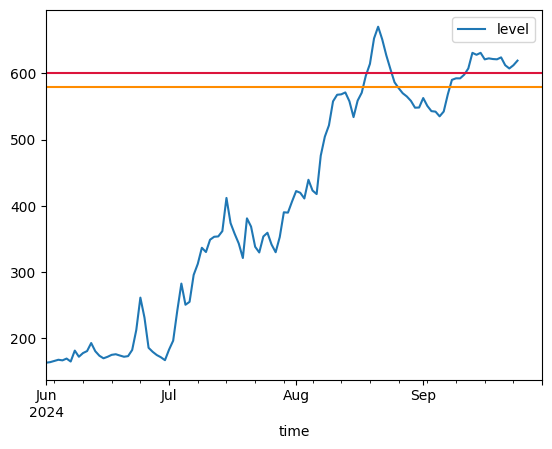

In [171]:
ax = df_locale_recent[df_locale_recent["season"] == 2024].plot(
    x="time", y="level"
)
ax.axhline(600, color="crimson")
ax.axhline(580, color="darkorange")